# Random Forest - Telco Customer Churn

Required project scenarios:
1. Baseline regularized Random Forest
2. Feature scaling comparison
3. `n_estimators` comparison: 50, 100, and 200

The same tree-regularization parameters are used in every scenario so the
comparisons isolate scaling and `n_estimators`, not changes in tree depth.



In [52]:
# 0. Import libraries

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

print("Libraries loaded successfully")



Libraries loaded successfully


## 1. Load and Explore the Dataset



In [53]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = BASE_DIR / "Dataset" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()



Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
print("=== Data Types ===")
print(df_raw.dtypes)

print("\n=== Missing Values Reported by pandas ===")
print(df_raw.isnull().sum())

print("\n=== Churn Distribution ===")
print(df_raw["Churn"].value_counts())
print(df_raw["Churn"].value_counts(normalize=True).round(4))



=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values Reported by pandas ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contra

## 2. Preprocessing

Preprocessing is fitted only on the training data:

- Remove `customerID`
- Convert `TotalCharges` to numeric
- Fill missing numeric values with the training median
- Fill missing categorical values with the training mode
- One-hot encode categorical features
- Use a stratified 80/20 train-test split



In [55]:
X_raw = df_raw.drop(columns=["customerID", "Churn"]).copy()
X_raw["TotalCharges"] = pd.to_numeric(X_raw["TotalCharges"], errors="coerce")
y = df_raw["Churn"].map({"No": 0, "Yes": 1})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_columns = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            drop="first",
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_columns,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_array = preprocessor.fit_transform(X_train_raw)
X_test_array = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train_raw.index,
)
X_test = pd.DataFrame(
    X_test_array,
    columns=feature_names,
    index=X_test_raw.index,
)

# Do not scale SeniorCitizen because it is a binary indicator.
CONTINUOUS_COLUMNS = ["tenure", "MonthlyCharges", "TotalCharges"]

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")
print(f"Number of encoded features: {X_train.shape[1]}")



Train size: (5634, 30)
Test size: (1409, 30)
Train churn rate: 0.265
Test churn rate: 0.265
Number of encoded features: 30


## 3. Helper Functions



## Scenario 1 - Baseline Regularized Random Forest

Goal: establish the initial performance of the regularized Random Forest
without feature scaling.



In [57]:
baseline_result = run_rf(
    X_train,
    X_test,
    y_train,
    y_test,
    n_estimators=100,
)

print_result("Scenario 1 - Baseline Regularized RF", baseline_result)
print()
print(
    classification_report(
        y_test,
        baseline_result["y_pred"],
        target_names=["No Churn", "Churn"],
    )
)



=== Scenario 1 - Baseline Regularized RF ===
Train Accuracy: 0.8431
Test Accuracy : 0.8020
Accuracy Gap  : 0.0411
Accuracy    : 0.8020
Precision   : 0.6678
Recall      : 0.5053
F1-Score    : 0.5753
ROC-AUC     : 0.8453

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



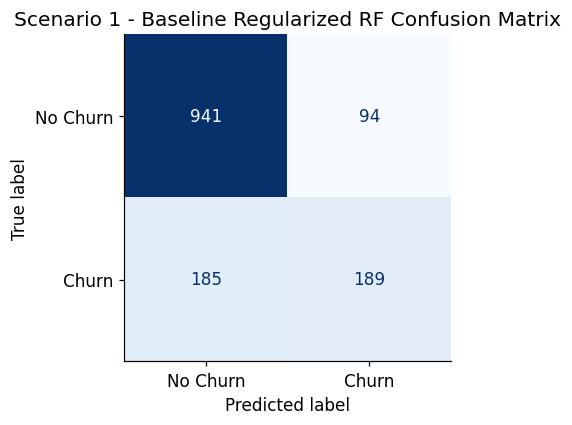

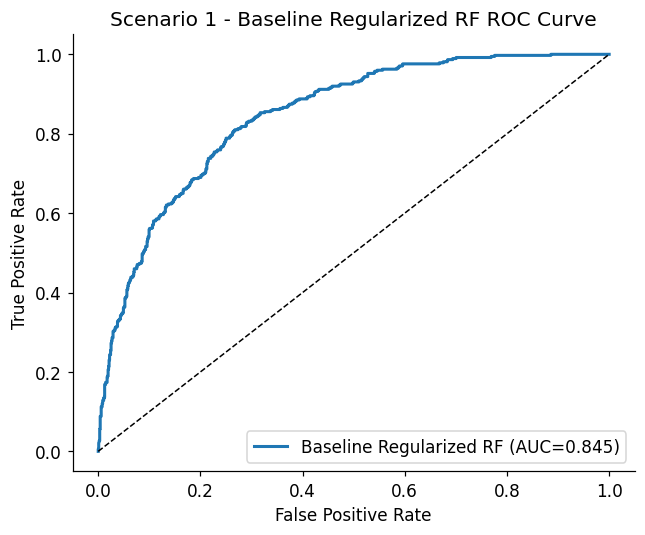

In [58]:
plot_confusion(
    y_test,
    baseline_result["y_pred"],
    "Scenario 1 - Baseline Regularized RF Confusion Matrix",
)

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_result["y_prob"],
)
plot_roc(
    {
        "Baseline Regularized RF": (
            baseline_fpr,
            baseline_tpr,
            baseline_result["metrics"]["ROC-AUC"],
        )
    },
    "Scenario 1 - Baseline Regularized RF ROC Curve",
)



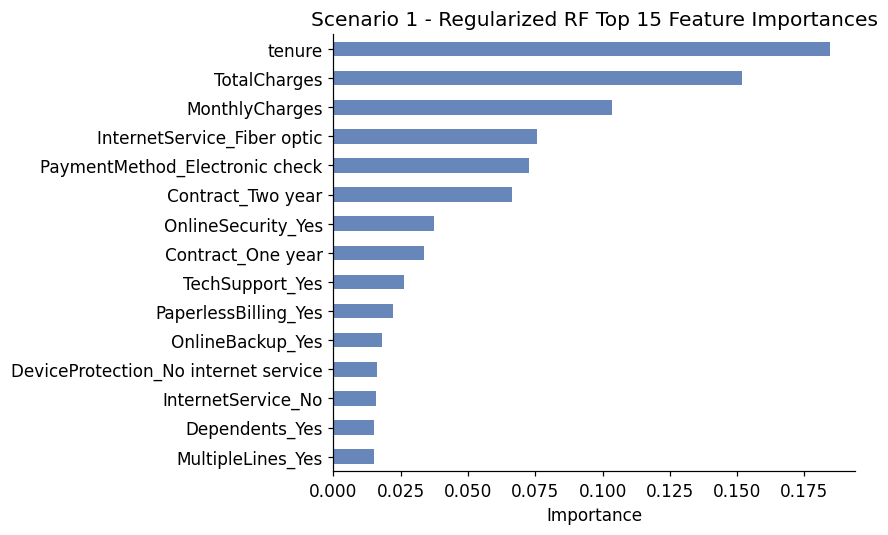

In [59]:
baseline_importance = pd.Series(
    baseline_result["model"].feature_importances_,
    index=X_train.columns,
)
top_15_baseline_features = baseline_importance.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_15_baseline_features.sort_values().plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    alpha=0.85,
)
ax.set_title("Scenario 1 - Regularized RF Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()



## Scenario 2 - Feature Scaling Comparison

- Version A: no scaling
- Version B: `StandardScaler` on continuous numerical features

Random Forest is tree-based, so scaling is not expected to make a
meaningful difference.



In [60]:
no_scaling_result = run_rf(
    X_train,
    X_test,
    y_train,
    y_test,
    n_estimators=100,
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[CONTINUOUS_COLUMNS] = scaler.fit_transform(
    X_train[CONTINUOUS_COLUMNS]
)
X_test_scaled[CONTINUOUS_COLUMNS] = scaler.transform(
    X_test[CONTINUOUS_COLUMNS]
)

scaling_result = run_rf(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    n_estimators=100,
)

print_result("Scenario 2A - No Scaling", no_scaling_result)
print()
print_result("Scenario 2B - StandardScaler", scaling_result)



=== Scenario 2A - No Scaling ===
Train Accuracy: 0.8431
Test Accuracy : 0.8020
Accuracy Gap  : 0.0411
Accuracy    : 0.8020
Precision   : 0.6678
Recall      : 0.5053
F1-Score    : 0.5753
ROC-AUC     : 0.8453

=== Scenario 2B - StandardScaler ===
Train Accuracy: 0.8429
Test Accuracy : 0.8020
Accuracy Gap  : 0.0409
Accuracy    : 0.8020
Precision   : 0.6678
Recall      : 0.5053
F1-Score    : 0.5753
ROC-AUC     : 0.8454


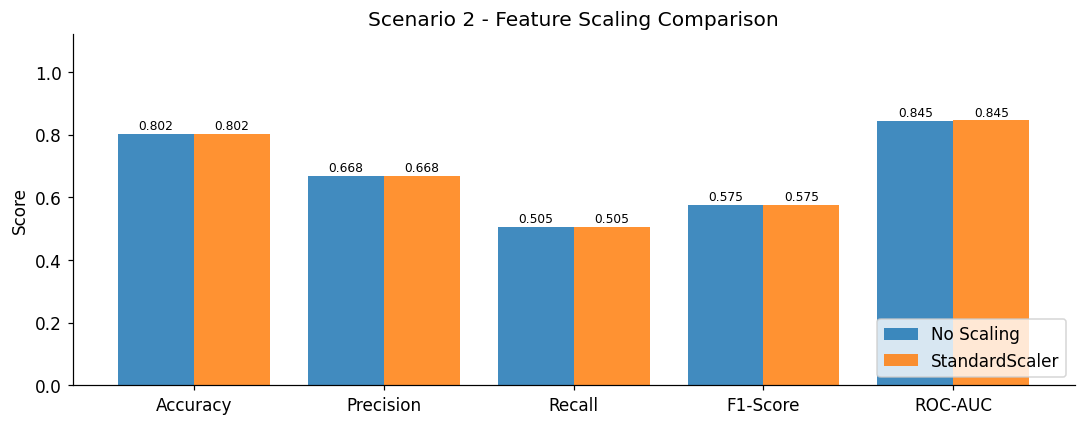

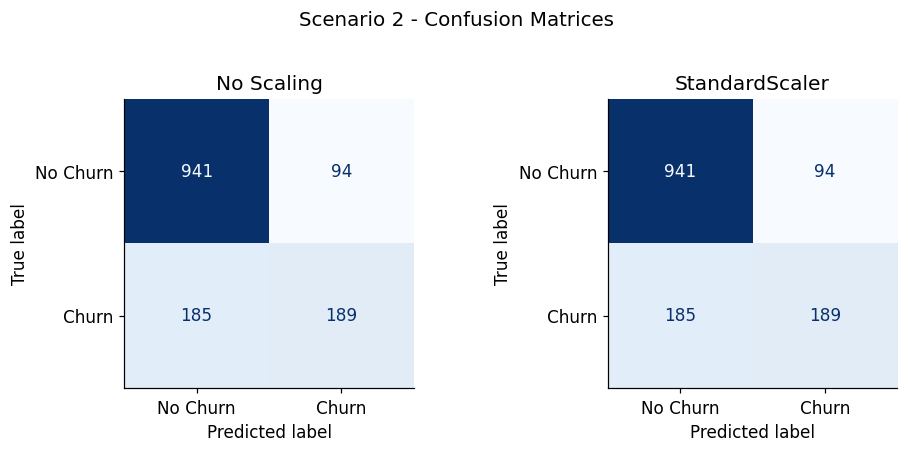

In [61]:
scenario_2_metrics = {
    "No Scaling": no_scaling_result["metrics"],
    "StandardScaler": scaling_result["metrics"],
}

plot_metrics_bar(
    scenario_2_metrics,
    "Scenario 2 - Feature Scaling Comparison",
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (label, result) in zip(
    axes,
    [
        ("No Scaling", no_scaling_result),
        ("StandardScaler", scaling_result),
    ],
):
    matrix = confusion_matrix(y_test, result["y_pred"])
    display = ConfusionMatrixDisplay(
        matrix,
        display_labels=["No Churn", "Churn"],
    )
    display.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(label)

plt.suptitle("Scenario 2 - Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



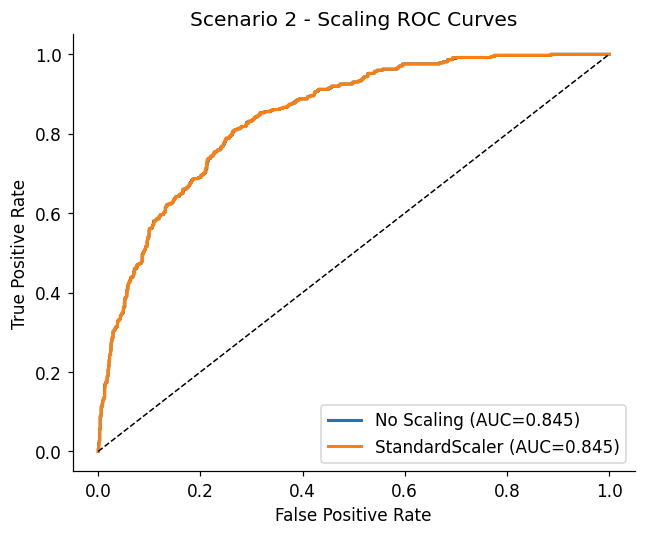

In [62]:
scenario_2_roc = {}

for label, result in [
    ("No Scaling", no_scaling_result),
    ("StandardScaler", scaling_result),
]:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        result["y_prob"],
    )
    scenario_2_roc[label] = (
        false_positive_rate,
        true_positive_rate,
        result["metrics"]["ROC-AUC"],
    )

plot_roc(
    scenario_2_roc,
    "Scenario 2 - Scaling ROC Curves",
)



In [63]:
print("=== Scenario 2 Metric Differences: Scaling - No Scaling ===")

for metric in no_scaling_result["metrics"]:
    difference = (
        scaling_result["metrics"][metric]
        - no_scaling_result["metrics"][metric]
    )
    print(f"{metric:<12}: {difference:+.4f}")

print("\nConclusion: scaling has little effect on Random Forest performance.")



=== Scenario 2 Metric Differences: Scaling - No Scaling ===
Accuracy    : +0.0000
Precision   : +0.0000
Recall      : +0.0000
F1-Score    : +0.0000
ROC-AUC     : +0.0001

Conclusion: scaling has little effect on Random Forest performance.


## Scenario 3 - Required `n_estimators` Comparison

Compare:

- `n_estimators=50`
- `n_estimators=100`
- `n_estimators=200`

All three models use the same regularized tree configuration. Only the
number of trees changes.



In [64]:
n_estimators_values = [50, 100, 200]
scenario_3_results = {}

for n_estimators in n_estimators_values:
    label = f"n={n_estimators}"
    scenario_3_results[label] = run_rf(
        X_train,
        X_test,
        y_train,
        y_test,
        n_estimators=n_estimators,
    )

print(
    f"{'Model':<10}"
    f"{'Train Acc':>12}"
    f"{'Test Acc':>12}"
    f"{'Gap':>10}"
    f"{'F1':>10}"
    f"{'ROC-AUC':>10}"
)
print("-" * 64)

for label, result in scenario_3_results.items():
    train_accuracy = result["train_accuracy"]
    test_accuracy = result["metrics"]["Accuracy"]

    print(
        f"{label:<10}"
        f"{train_accuracy:>12.4f}"
        f"{test_accuracy:>12.4f}"
        f"{train_accuracy - test_accuracy:>10.4f}"
        f"{result['metrics']['F1-Score']:>10.4f}"
        f"{result['metrics']['ROC-AUC']:>10.4f}"
    )



Model        Train Acc    Test Acc       Gap        F1   ROC-AUC
----------------------------------------------------------------
n=50            0.8424      0.8013    0.0411    0.5706    0.8438
n=100           0.8431      0.8020    0.0411    0.5753    0.8453
n=200           0.8454      0.8020    0.0434    0.5740    0.8452


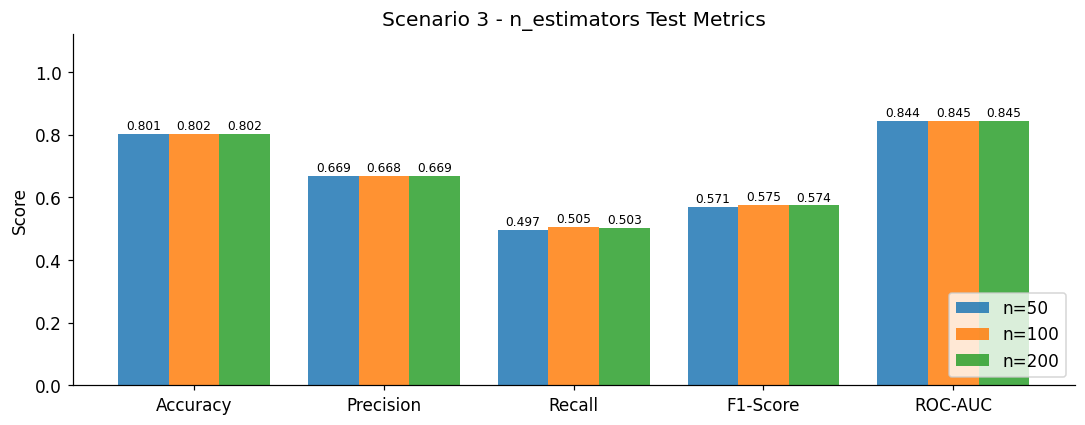

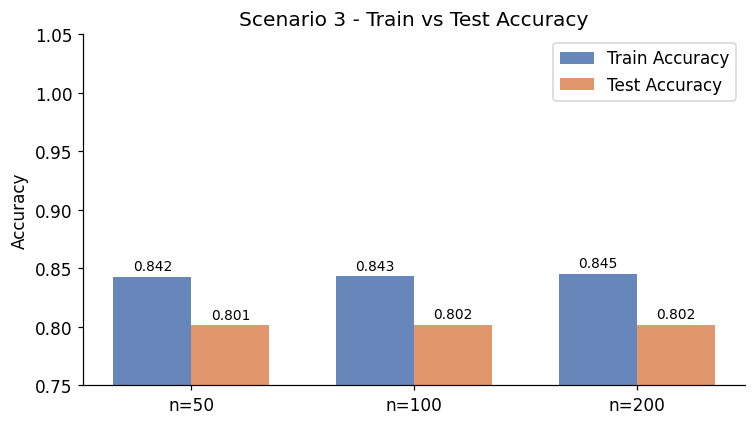

In [65]:
plot_metrics_bar(
    {
        label: result["metrics"]
        for label, result in scenario_3_results.items()
    },
    "Scenario 3 - n_estimators Test Metrics",
)

labels = list(scenario_3_results)
train_accuracies = [
    result["train_accuracy"]
    for result in scenario_3_results.values()
]
test_accuracies = [
    result["metrics"]["Accuracy"]
    for result in scenario_3_results.values()
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
train_bars = ax.bar(
    x - width / 2,
    train_accuracies,
    width,
    label="Train Accuracy",
    color="#4C72B0",
    alpha=0.85,
)
test_bars = ax.bar(
    x + width / 2,
    test_accuracies,
    width,
    label="Test Accuracy",
    color="#DD8452",
    alpha=0.85,
)

for bars in [train_bars, test_bars]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.75, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Scenario 3 - Train vs Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()



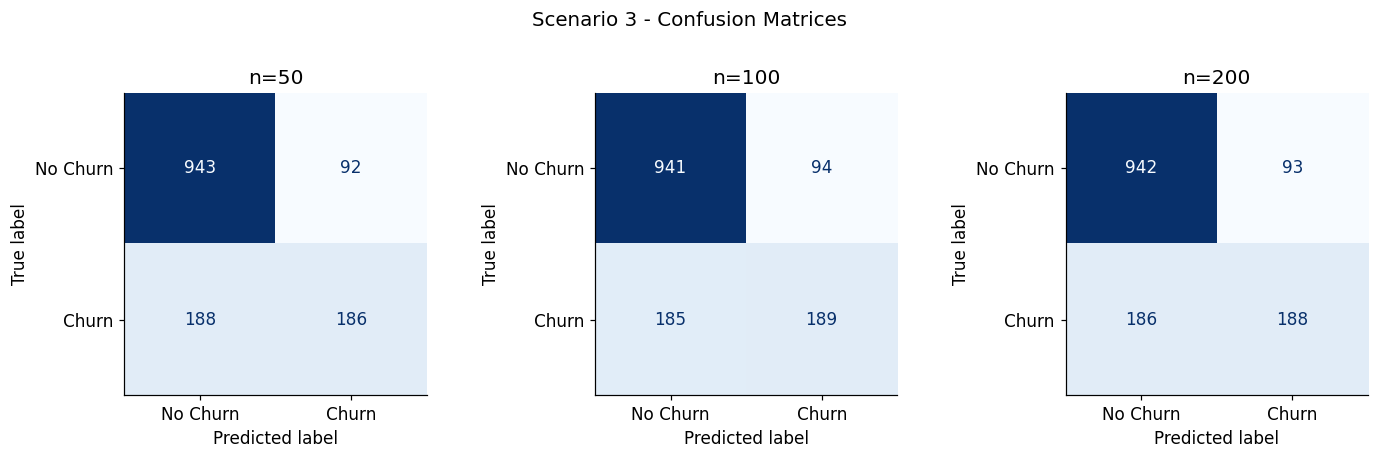

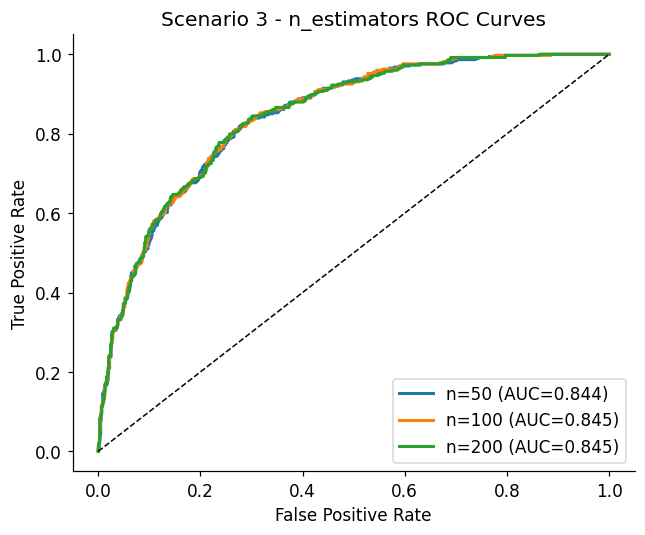

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (label, result) in zip(axes, scenario_3_results.items()):
    matrix = confusion_matrix(y_test, result["y_pred"])
    display = ConfusionMatrixDisplay(
        matrix,
        display_labels=["No Churn", "Churn"],
    )
    display.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(label)

plt.suptitle("Scenario 3 - Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

scenario_3_roc = {}

for label, result in scenario_3_results.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        result["y_prob"],
    )
    scenario_3_roc[label] = (
        false_positive_rate,
        true_positive_rate,
        result["metrics"]["ROC-AUC"],
    )

plot_roc(
    scenario_3_roc,
    "Scenario 3 - n_estimators ROC Curves",
)



## Summary - Three Required Scenarios



In [67]:
all_results = {
    "S1 - Baseline Regularized RF": baseline_result["metrics"],
    "S2A - No Scaling": no_scaling_result["metrics"],
    "S2B - Scaling": scaling_result["metrics"],
}

for label, result in scenario_3_results.items():
    all_results[f"S3 - {label}"] = result["metrics"]

summary_df = pd.DataFrame(all_results).T.round(4)
print(summary_df.to_string())



                              Accuracy  Precision  Recall  F1-Score  ROC-AUC
S1 - Baseline Regularized RF    0.8020     0.6678  0.5053    0.5753   0.8453
S2A - No Scaling                0.8020     0.6678  0.5053    0.5753   0.8453
S2B - Scaling                   0.8020     0.6678  0.5053    0.5753   0.8454
S3 - n=50                       0.8013     0.6691  0.4973    0.5706   0.8438
S3 - n=100                      0.8020     0.6678  0.5053    0.5753   0.8453
S3 - n=200                      0.8020     0.6690  0.5027    0.5740   0.8452


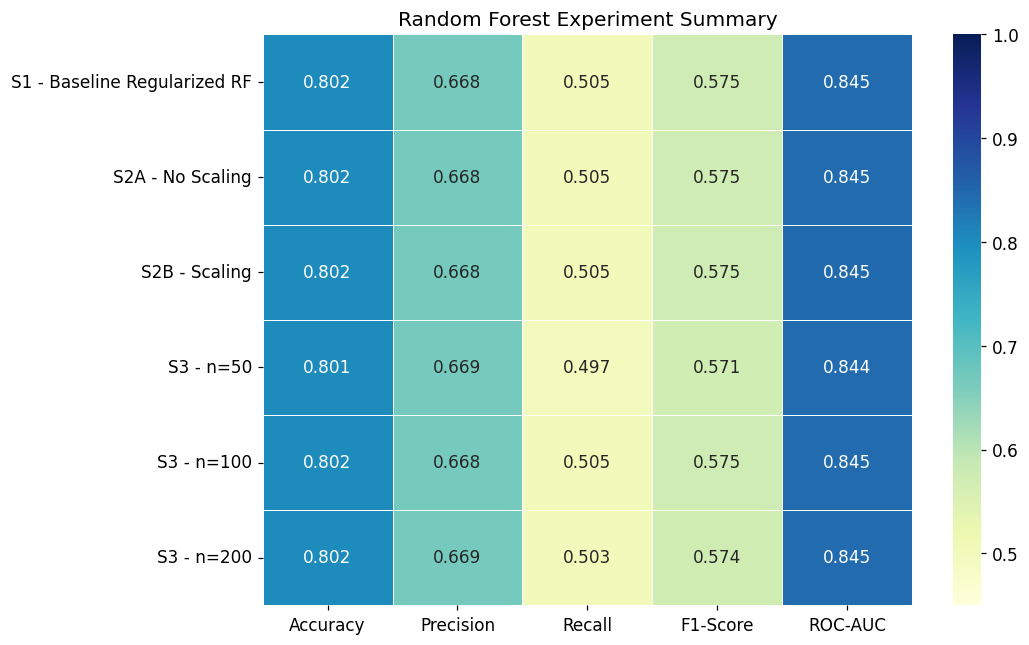

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    summary_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    vmin=0.45,
    vmax=1.0,
)
ax.set_title("Random Forest Experiment Summary")
plt.tight_layout()
plt.show()



## Conclusion

- Every model uses the same regularized tree settings: `max_depth=12`,
  `min_samples_split=20`, `min_samples_leaf=2`, and `max_features="log2"`.
- These restrictions reduce memorization and keep the train-test accuracy
  gap substantially smaller than an unrestricted Random Forest.
- Feature scaling has little effect because Random Forest uses decision
  thresholds rather than distance calculations.
- Scenario 3 isolates the effect of increasing the number of trees while
  keeping the regularization parameters fixed.
- Because the target is imbalanced, Accuracy must be interpreted together
  with Precision, Recall, F1-Score, and ROC-AUC.
